# Combination violin prediction plots for manuscript

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/readii_2_roqc


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from damply import dirs
import pandas as pd

## Global variables

In [ ]:
# Negative control name mapping for plots
nc_mapping = {
    'original_full':'Original',    
    'randomized_roi':"ROI - Random",
    'sampled_roi':'ROI - Sample',
    'shuffled_roi':'ROI - Shuffle',
    'randomized_non_roi':'Background - Random',
    'sampled_non_roi':'Background - Sample',
    'shuffled_non_roi':'Background - Shuffle',
    'randomized_full':'Full - Random',
    'sampled_full':'Full - Sample',
    'shuffled_full':'Full - Shuffle'
}

# Negative control name sort order for plots
nc_categories = ['Original', 
                'ROI - Random', 
                'ROI - Sample', 
                'ROI - Shuffle', 
                'Background - Random', 
                'Background - Sample', 
                'Background - Shuffle', 
                'Full - Random', 
                'Full - Sample', 
                'Full - Shuffle']

xtick_labels = [lbl.replace(" - ", "\n") for lbl in nc_categories]

In [ ]:
# Palettes for plotting
blue_palette = ['#003396', '#3373C4', '#86CEFA']
grey_palette = ['#4C5C68', '#899097', '#C5C3C6']
grey2_palete = ['#515151', "#737373", '#959595']
vibrant_palette = ['#FF6F40', '#4ECDC4', '#F69C00']

region_palette = ['#D50032', '#009B77', '#005B96'] #ROI, background, full

region10 = [
'#AB63FA',
'#EF553B',
# '#ab3a27',
#'#6b2115',
'#00CC96',
# '#00916a',
#'#005b41',
# '#91a2ff',
'#636EFA',
#'#3a4099'
]

region10_v2 = [
'#AB63FA',
'#e35157',
'#D50032',
'#980021',
'#5bb194',
'#009b77',
'#006d53',
'#7ca3c6',
'#2c6da2',
'#004d80',
]

In [ ]:
['#AB63FA', "#EB6750" '#EF553B', '#00CC96', '#636EFA',]

In [5]:
def prediction_violin(data:pd.DataFrame,
                      x:str | None = None,
                      y:str | None = None,
                      hue:str | None = None,
                      hue_order:list[str] | None = None,
                      palette:str | None = None,
                      gap:float = 0.01,
                      legend: str | bool = False,
                      random_line:float | None = 0.5,
                      random_line_color:str = 'black',
                      vol_line:float | None = None,
                      vol_line_color:str = 'red',
                      y_bound:list[float] = [0.25, 0.95],
                      xlabel:str = '',
                      xtick_labels:list[str] = [],
                      ylabel:str = '',
                      label_size: float = 11,
                      ax:plt.Axes | None = None,
                      figsize = tuple | None
                      ) -> plt.Figure:

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Plot c-index violin plots for each dataset and image type
    sns.violinplot(
        data=data, 
        x=x, 
        y=y, 
        hue=hue, 
        hue_order=hue_order, 
        palette=palette,
        gap=gap,
        legend=legend,
        ax=ax
    )

    # Plot the volume prediction lines for each dataset
    if vol_line is not None:
        ax.axhline(y=vol_line, color=vol_line_color, linestyle='dashdot')

    if random_line is not None:
        # Plot random guess line at 0.5
        ax.axhline(y=[random_line], color=random_line_color, linestyle='dashed', linewidth=1)

    ax.set_ybound(y_bound[0], y_bound[1])
    ax.set_xlabel(xlabel, fontsize=label_size)
    ax.set_ylabel(ylabel, fontsize=label_size)

    ax.tick_params('x', labelrotation=60, labelsize=13, labelrotation_mode='xtick')
    # ax.set_xticklabels(xtick_labels)
    ax.spines[['right', 'top']].set_visible(False)

    return ax

## Aerts OS Signature

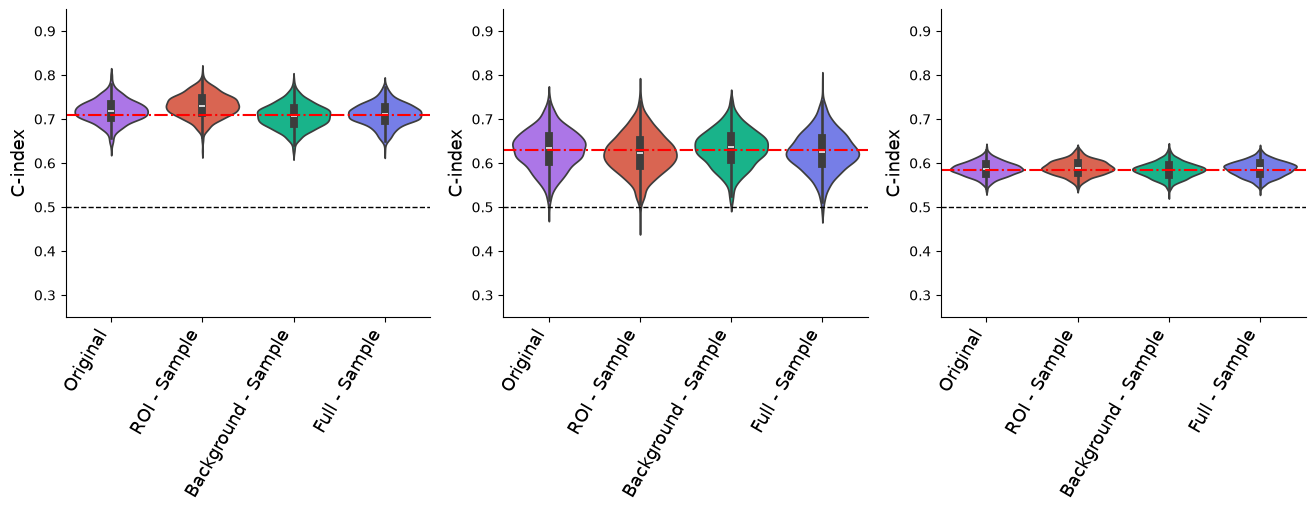

In [32]:
signature = "aerts_original"
dataset_name = ['RADCURE_windowed', 'HEAD-NECK-RADIOMICS-HN1_windowed', 'NSCLC-Radiomics_windowed']
split = ['TEST', '', '']
vol_lines = [0.710, 0.629, 0.585]

evaluation_metric = "C-index"
all_predictions = []

fig, ax = plt.subplots(1, 3, figsize = (16,4))#31,8))

for idx, dataset in enumerate(dataset_name):

    bootstrap_predictions_path = dirs.RESULTS / f"TCIA_{dataset}" / "prediction" / signature / split[idx] / "bootstrap_1000" 

    predictions = {}
    for image_predictions_file in sorted(bootstrap_predictions_path.rglob('*.csv')):
        image_type = str(image_predictions_file.stem)
        image_type_predictions = pd.read_csv(image_predictions_file, index_col=0)

        predictions[image_type] = image_type_predictions['C-index']

    dataset_preds = pd.DataFrame.from_dict(predictions)
  
    # Rename image type columns to nicer formats for plotting
    dataset_preds = dataset_preds.rename(columns = nc_mapping)
    # Sort into desired plot order
    dataset_preds = dataset_preds[nc_categories]

    prediction_violin(
        dataset_preds,
        gap=0,
        palette = region10,
        vol_line = vol_lines[idx],
        ylabel=evaluation_metric,
        xtick_labels=nc_categories,
        legend=False,
        label_size=13,
        ax = ax[idx],
    )

    # Add dataset name column
    dataset_preds['dataset'] = dataset.removesuffix("_windowed")

In [33]:
fig.savefig(fname="aerts_os_violin_transparent.png", transparent=True)

## Choi HPV Status Signature

Results generated in sandbox/analysis/hpv_prediction.ipynb

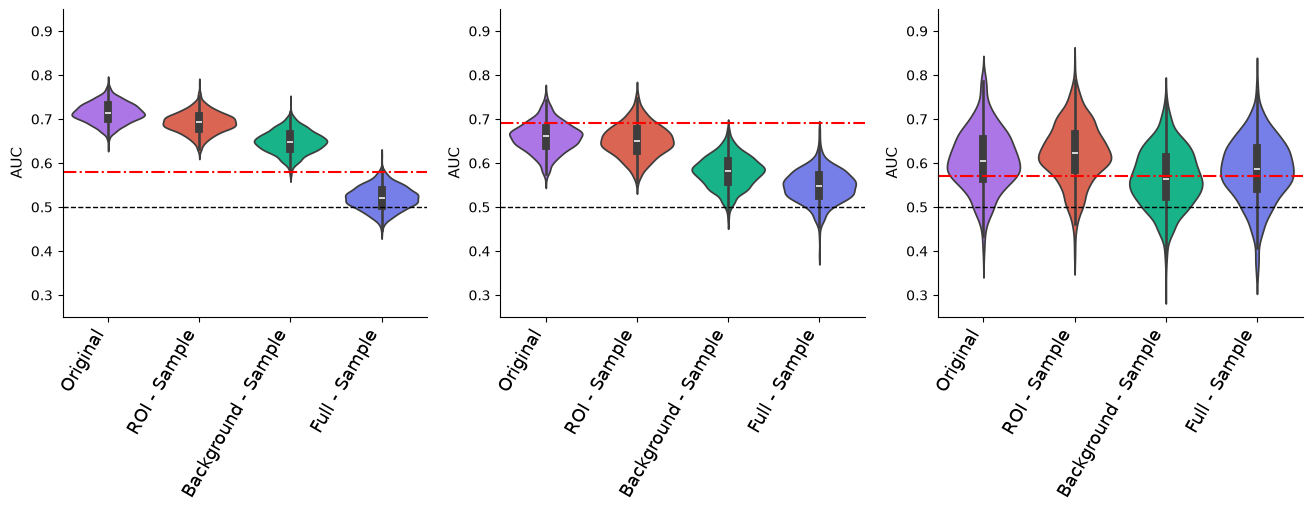

In [30]:
signature = "choi_opc_hpv_2020_hpv_status"
dataset_name = ['RADCURE_windowed', 'RADCURE_windowed', 'HEAD-NECK-RADIOMICS-HN1_windowed', ]
short_data = ['radcure', 'radcure', 'hn1', ]
split = ['_train', '_test', '']
vol_lines = [0.58, 0.69, 0.57]

evaluation_metric = "AUC"

fig, ax = plt.subplots(1, 3, figsize = (16,4))#31,8))

for idx, dataset in enumerate(dataset_name):

    bootstrap_predictions_path = dirs.RESULTS / f"TCIA_{dataset}" / "prediction" / signature / f"lr_bootstrap_{short_data[idx]}{split[idx]}.csv"
    bootstrap_predictions = pd.read_csv(bootstrap_predictions_path)

    # Rename image type columns to nicer formats for plotting
    dataset_preds = bootstrap_predictions.rename(columns = nc_mapping)
    # Sort into desired plot order
    dataset_preds = dataset_preds[nc_categories]

    prediction_violin(
            dataset_preds,
            gap=0,
            palette = region10,
            vol_line = vol_lines[idx],
            ylabel=evaluation_metric,
            xtick_labels=nc_categories,
            legend=False,
            ax = ax[idx]
        )

    # Add dataset name column
    dataset_preds['dataset'] = f"{dataset.removesuffix('_windowed')}{split[idx]}"

In [31]:
fig.savefig(fname="choi_hpv_violin_transparent.png", transparent=True)

## Choi OS signature

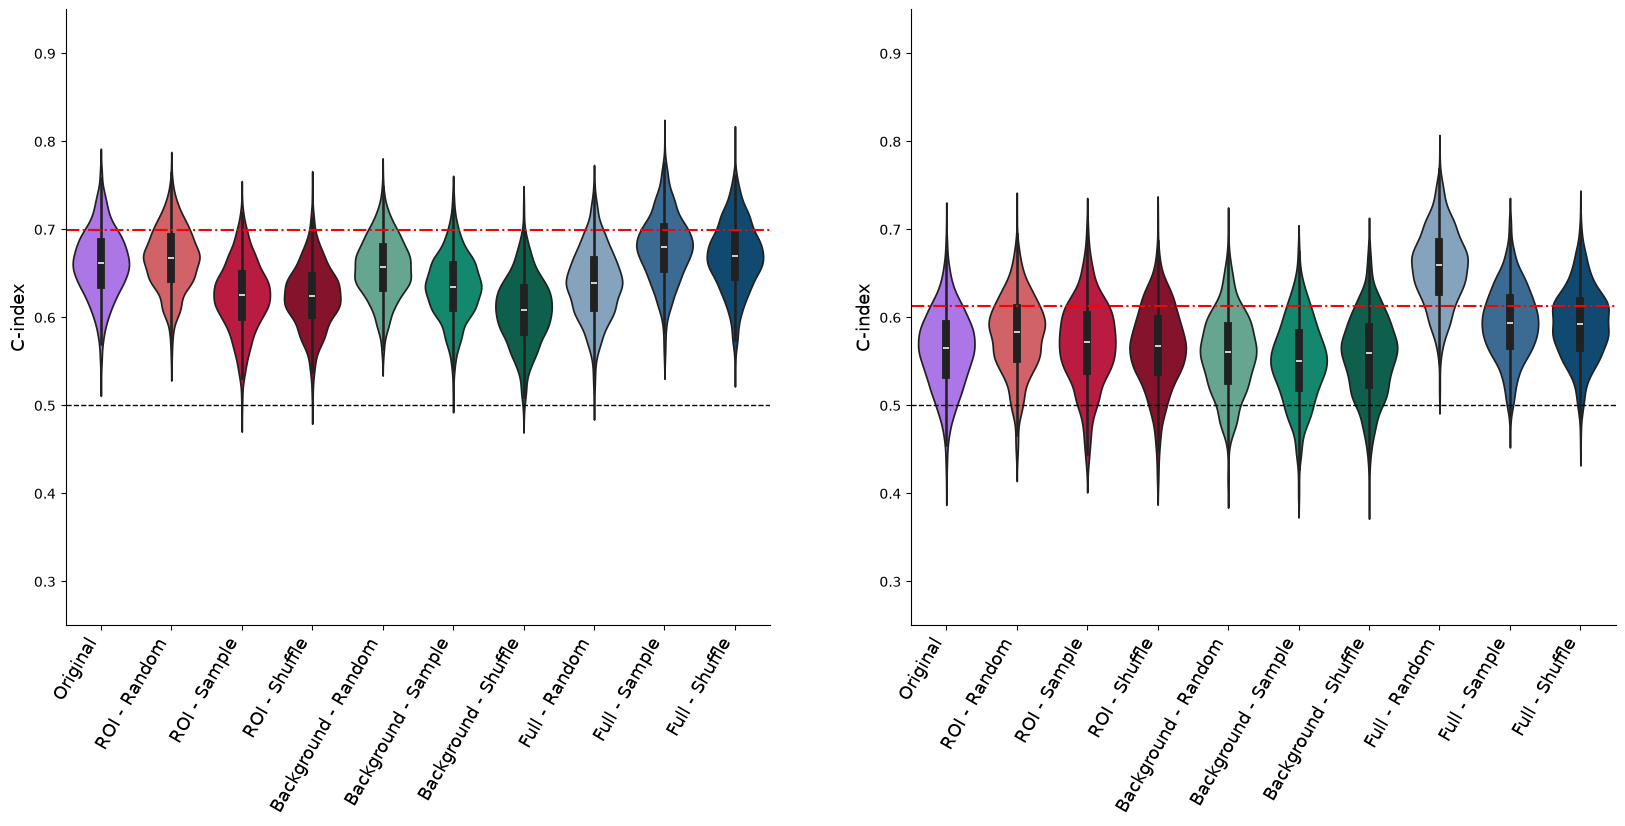

In [136]:
signature = "choi_opc_os_2020"
dataset_name = ['RADCURE_windowed', 'HEAD-NECK-RADIOMICS-HN1_windowed', ]
split = ['TEST', '']
vol_lines = [0.699, 0.613]

evaluation_metric = "C-index"
predictions = []

fig, ax = plt.subplots(1, 2, figsize = (20,8))

for idx, dataset in enumerate(dataset_name):

    bootstrap_predictions_path = dirs.RESULTS / f"TCIA_{dataset}" / "prediction" / signature / split[idx] / "bootstrap_1000" 

    predictions = {}
    for image_predictions_file in sorted(bootstrap_predictions_path.rglob('*.csv')):
        image_type = str(image_predictions_file.stem)
        image_type_predictions = pd.read_csv(image_predictions_file, index_col=0)

        predictions[image_type] = image_type_predictions['C-index']

    dataset_preds = pd.DataFrame.from_dict(predictions)

    # Rename image type columns to nicer formats for plotting
    dataset_preds = dataset_preds.rename(columns = nc_mapping)
    # Sort into desired plot order
    dataset_preds = dataset_preds[nc_categories]

    prediction_violin(
        dataset_preds,
        gap=0,
        palette = region10_v2,
        vol_line = vol_lines[idx],
        ylabel=evaluation_metric,
        xtick_labels=nc_categories,
        legend=False,
        label_size=13,
        ax = ax[idx]
    )

    # Add dataset name column
    dataset_preds['dataset'] = dataset.removesuffix("_windowed")

# Combined violin plots for all three datasets

## Choi OS Signature

In [ ]:
signature = "choi_opc_os_2020"
dataset_name = ['RADCURE_windowed', 'HEAD-NECK-RADIOMICS-HN1_windowed', ]
split = ['TEST', '']

evaluation_metric = "C-index"
predictions = []

for idx, dataset in enumerate(dataset_name):

    bootstrap_predictions_path = dirs.RESULTS / f"TCIA_{dataset}" / "prediction" / signature / split[idx] / "bootstrap_1000" 
   
    for image_predictions_file in sorted(bootstrap_predictions_path.rglob('*.csv')):
        image_type = str(image_predictions_file.stem)
        image_type_predictions = pd.read_csv(image_predictions_file, index_col=0)

        image_type_predictions['dataset'] = dataset.removesuffix("_windowed")
        image_type_predictions['image_type'] = image_type

        predictions.append(
            image_type_predictions
        )

all_preds_df = pd.concat(predictions)

all_preds_df = all_preds_df.replace({"image_type": nc_mapping})
all_preds_df.image_type = pd.Categorical(all_preds_df.image_type,
                                        categories = nc_categories)
all_preds_df = all_preds_df.sort_values('image_type')

/tmp/ipykernel_713738/3894074165.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xtick_labels)


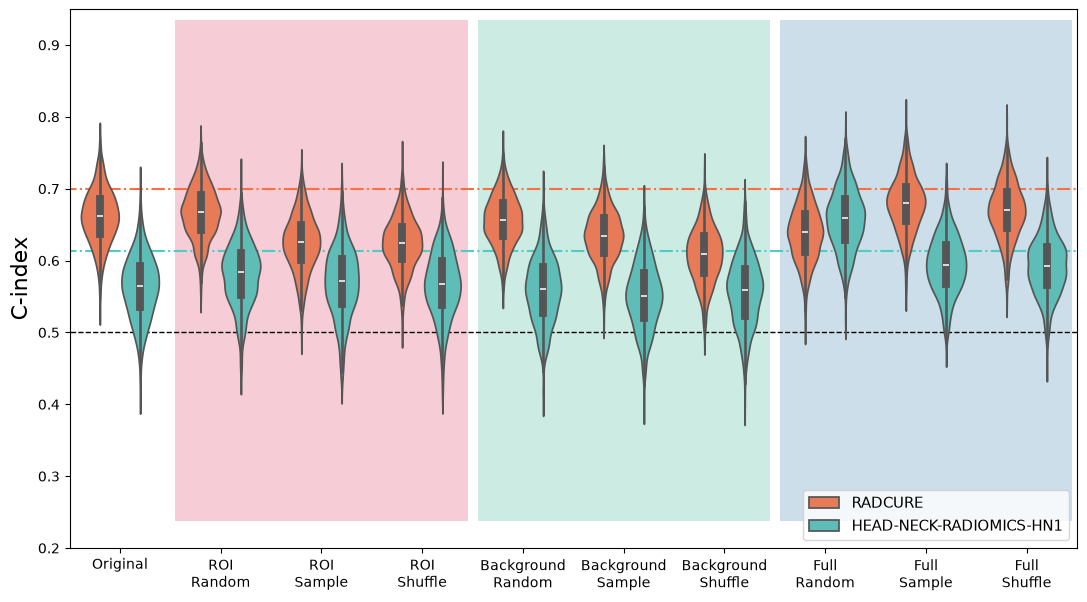

In [ ]:
fig, ax = plt.subplots(figsize=(13,7))

# Plot coloured rectangles behind the violins to visualize the negative control regions
yspan_min = 0.05
yspan_max = 0.98
plt.axvspan(0.55, 3.45, yspan_min, yspan_max, facecolor=region_palette[0], alpha=0.2, zorder=0)
plt.axvspan(3.55, 6.45, yspan_min, yspan_max,facecolor=region_palette[1], alpha=0.2, zorder=0)
plt.axvspan(6.55, 9.45, yspan_min, yspan_max, facecolor=region_palette[2], alpha=0.2, zorder=0)

# Plot the volume prediction lines for each dataset
plt.hlines(y=[0.699, 0.613], xmin=-1, xmax=10, colors=vibrant_palette[:2], linestyles='dashdot', zorder=1)

# Plot random guess line at 0.5
plt.hlines(y=[0.5], xmin=-1, xmax=10, color='black', linestyles='dashed', zorder=1, linewidth=1)

# Plot c-index violin plots for each dataset and image type
sns.violinplot(data=all_preds_df, x='image_type', 
               y=evaluation_metric, 
               hue='dataset', 
               hue_order=['RADCURE', 'HEAD-NECK-RADIOMICS-HN1'], 
               palette=vibrant_palette[:2],
               gap=0.01
               )

ax.set_ybound(0.2, 0.95)
plt.xlabel('')
plt.ylabel('C-index', fontsize=16)
plt.legend(loc='lower right', fontsize=11)
ax.set_xticklabels(xtick_labels)
plt.show()

## Choi HPV

In [61]:
signature = "choi_opc_hpv_2020_hpv_status"
dataset_name = ['HEAD-NECK-RADIOMICS-HN1_windowed', 'RADCURE_windowed', 'RADCURE_windowed']
short_data = ['hn1', 'radcure', 'radcure']
split = ['', '_train', '_test']

evaluation_metric = "AUC"
predictions = []

for idx, dataset in enumerate(dataset_name):

    bootstrap_predictions_path = dirs.RESULTS / f"TCIA_{dataset}" / "prediction" / signature / f"lr_bootstrap_{short_data[idx]}{split[idx]}.csv"
    bootstrap_predictions = pd.read_csv(bootstrap_predictions_path)

    melt_predictions = bootstrap_predictions.melt(var_name="image_type",
                                                  value_name="AUC")

    # if short_data[idx] == 'radcure':
    #     melt_predictions['dataset'] = f'RADCURE{split[idx]}'
    # else:
    melt_predictions['dataset'] = f"{dataset.removesuffix('_windowed')}{split[idx]}"

    predictions.append(melt_predictions)

all_preds_df = pd.concat(predictions)

all_preds_df = all_preds_df.replace({"image_type": nc_mapping})
all_preds_df.image_type = pd.Categorical(all_preds_df.image_type,
                                        categories = nc_categories)
all_preds_df = all_preds_df.sort_values('image_type')

/tmp/ipykernel_713738/2056354083.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xtick_labels)


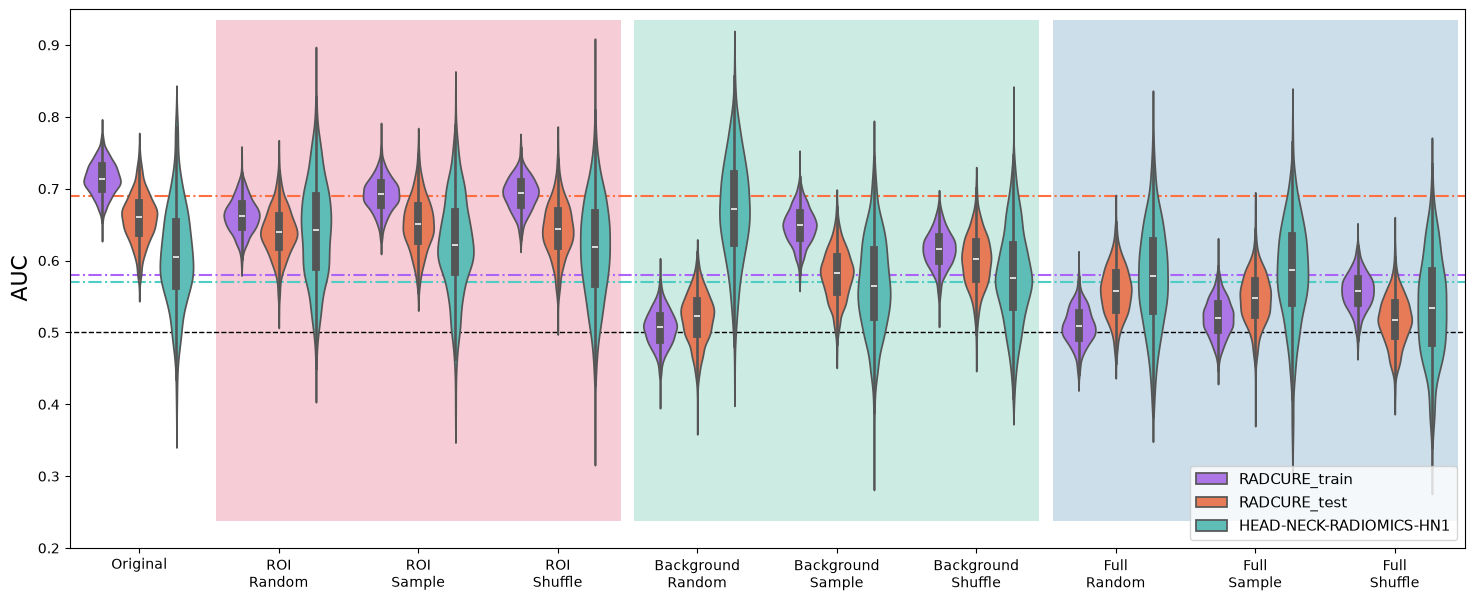

In [ ]:
fig, ax = plt.subplots(figsize=(18,7))

p_vibrant = ['#AB63FA'] + vibrant_palette[:2]

# Plot coloured rectangles behind the violins to visualize the negative control regions
yspan_min = 0.05
yspan_max = 0.98
plt.axvspan(0.55, 3.45, yspan_min, yspan_max, facecolor=region_palette[0], alpha=0.2, zorder=0)
plt.axvspan(3.55, 6.45, yspan_min, yspan_max,facecolor=region_palette[1], alpha=0.2, zorder=0)
plt.axvspan(6.55, 9.45, yspan_min, yspan_max, facecolor=region_palette[2], alpha=0.2, zorder=0)

# Plot the volume prediction lines for each dataset
plt.hlines(y=[0.58, 0.69, 0.57], xmin=-1, xmax=10, colors=p_vibrant, linestyles='dashdot', zorder=1)

# Plot random guess line at 0.5
plt.hlines(y=[0.5], xmin=-1, xmax=10, color='black', linestyles='dashed', zorder=1, linewidth=1)

# Plot c-index violin plots for each dataset and image type
sns.violinplot(data=all_preds_df, x='image_type', 
               y=evaluation_metric, 
               hue='dataset', 
               hue_order=['RADCURE_train', 'RADCURE_test', 'HEAD-NECK-RADIOMICS-HN1'], 
               palette=p_vibrant,
               gap=0.01
               )

ax.set_ybound(0.2, 0.95)
plt.xlabel('')
plt.ylabel('AUC', fontsize=16)
plt.legend(loc='lower right', fontsize=11)
ax.set_xticklabels(xtick_labels)
plt.show()

## Aerts

In [ ]:
# Old combined violin plots for all datasets
# fig, ax = plt.subplots(1,3,figsize=(18,7))

# # Plot coloured rectangles behind the violins to visualize the negative control regions
# yspan_min = 0.05
# yspan_max = 0.98
# plt.axvspan(0.55, 3.45, yspan_min, yspan_max, facecolor=region_palette[0], alpha=0.2, zorder=0)
# plt.axvspan(3.55, 6.45, yspan_min, yspan_max,facecolor=region_palette[1], alpha=0.2, zorder=0)
# plt.axvspan(6.55, 9.45, yspan_min, yspan_max, facecolor=region_palette[2], alpha=0.2, zorder=0)

# # Plot the volume prediction lines for each dataset
# plt.hlines(y=[0.710, 0.629, 0.585], xmin=-1, xmax=10, colors=vibrant_palette, linestyles='dashdot', zorder=1)

# # Plot random guess line at 0.5
# plt.hlines(y=[0.5], xmin=-1, xmax=10, color='black', linestyles='dashed', zorder=1, linewidth=1)

# # Plot c-index violin plots for each dataset and image type
# sns.violinplot(data=all_preds_df, x='image_type', 
#                y=evaluation_metric, 
#                hue='dataset', 
#                hue_order=['RADCURE', 'HEAD-NECK-RADIOMICS-HN1', 'NSCLC-Radiomics'], 
#                palette=vibrant_palette,
#                gap=0.01
#                )

# ax.set_ybound(0.2, 0.95)
# plt.xlabel('')
# plt.ylabel('C-index', fontsize=16)
# plt.legend(loc='lower right', fontsize=11)
# ax.set_xticklabels(xtick_labels)
# plt.show()